# Diabetes - Linear Discriminant Analysis (LDA)

### Imports and Loading Data

In [5]:
#import tools and data for training and preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

diabetes_dataframe_training = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

diabetes_dataframe_training.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82    218334
         1.0       0.31      0.78      0.44     35346

    accuracy                           0.72    253680
   macro avg       0.63      0.75      0.63    253680
weighted avg       0.86      0.72      0.76    253680



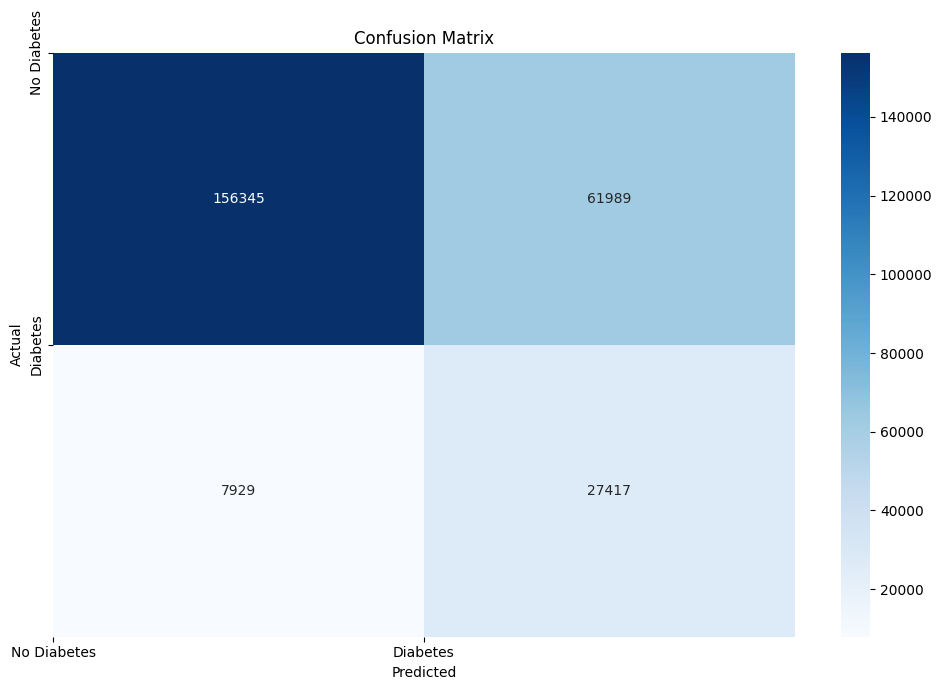

In [6]:
# split the data into features and target variable

X_train = diabetes_dataframe_training.drop(columns=['Diabetes_binary'])
y_train = diabetes_dataframe_training['Diabetes_binary']

# testing set split
diabetes_dataframe_testing = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_health_indicators_BRFSS2015.csv')

X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

# make predictions using the model
model = LinearDiscriminantAnalysis()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# evaluate the model
print(classification_report(y_test, y_pred))

# plot the confusion matrix
plt.figure(figsize=(10, 7))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.yticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.tight_layout()

plt.show()

### Using gridsearch for hyperparameter tuning

In [7]:
# Define the parameter grid for LDA
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto'] + [0.1, 0.2, 0.5, 0.7, 1.0]  # shrinkage is only applicable for 'lsqr' and 'eigen'
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=LinearDiscriminantAnalysis(), param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test Set Accuracy:", test_score)

Best Parameters: {'shrinkage': 'auto', 'solver': 'lsqr'}
Best Cross-Validation Score: 0.7472982295468278
Test Set Accuracy: 0.7243771680857773


c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 105.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Malik\AppDa

Hyperparameter tuning did not improve model performance significantly, but since LDA is a linear model we can tune the decision boundary!

For diabetes, moving the decision boundary towards the negative class is preferred since false positives are less dangerous than false negatives where patients may believe they do not have diabetes.

              precision    recall  f1-score   support

         0.0       0.96      0.70      0.80    218334
         1.0       0.30      0.80      0.43     35346

    accuracy                           0.71    253680
   macro avg       0.63      0.75      0.62    253680
weighted avg       0.86      0.71      0.75    253680



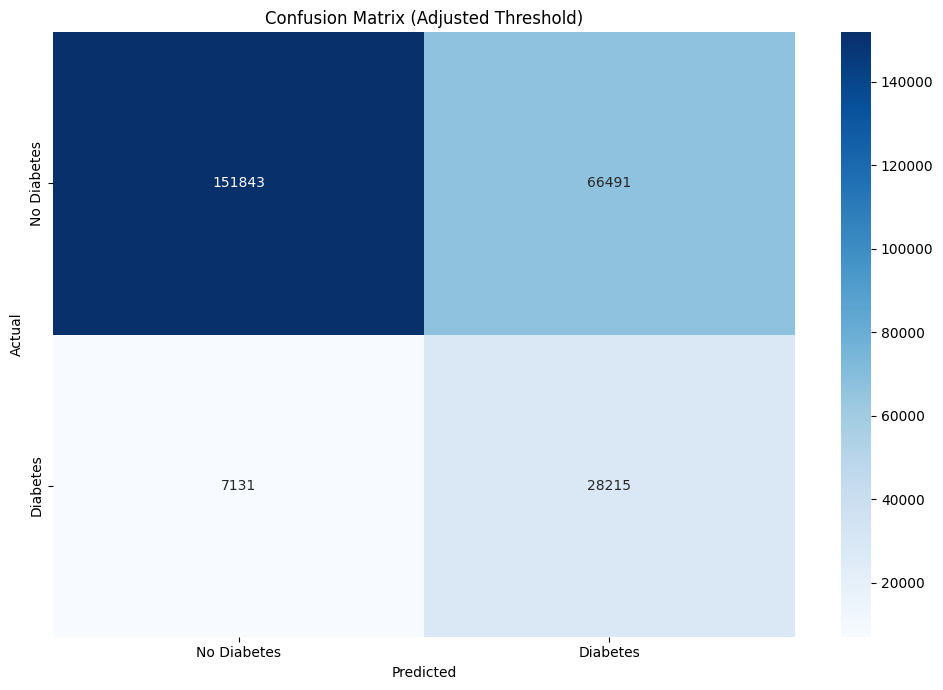

In [10]:
# Get the decision function scores
decision_scores = best_model.decision_function(X_test)

# Adjust the threshold to move the decision boundary
threshold = 0.0  # Default threshold is 0.0
adjusted_threshold = threshold - 0.1  # Shift the threshold towards the negative class
# Threshold needs to move without affecting model performance significantly
# any lower and it seems to affect the model performance

# Make predictions based on the adjusted threshold
adjusted_predictions = (decision_scores > adjusted_threshold).astype(int)

# Evaluate the adjusted predictions
print(classification_report(y_test, adjusted_predictions))

# Plot the confusion matrix for adjusted predictions
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, adjusted_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Adjusted Threshold)')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.yticks([0.5, 1.5], ['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.show()